Colonne rilevate: ['EdepNuc_keV', 'yNuc_keV_um', 'zNuc_mGy', 'EdepCyto_keV', 'yCyto_keV_um', 'zCyto_mGy', 'TotalTrackLength_um', 'CytoTrackLength_um']


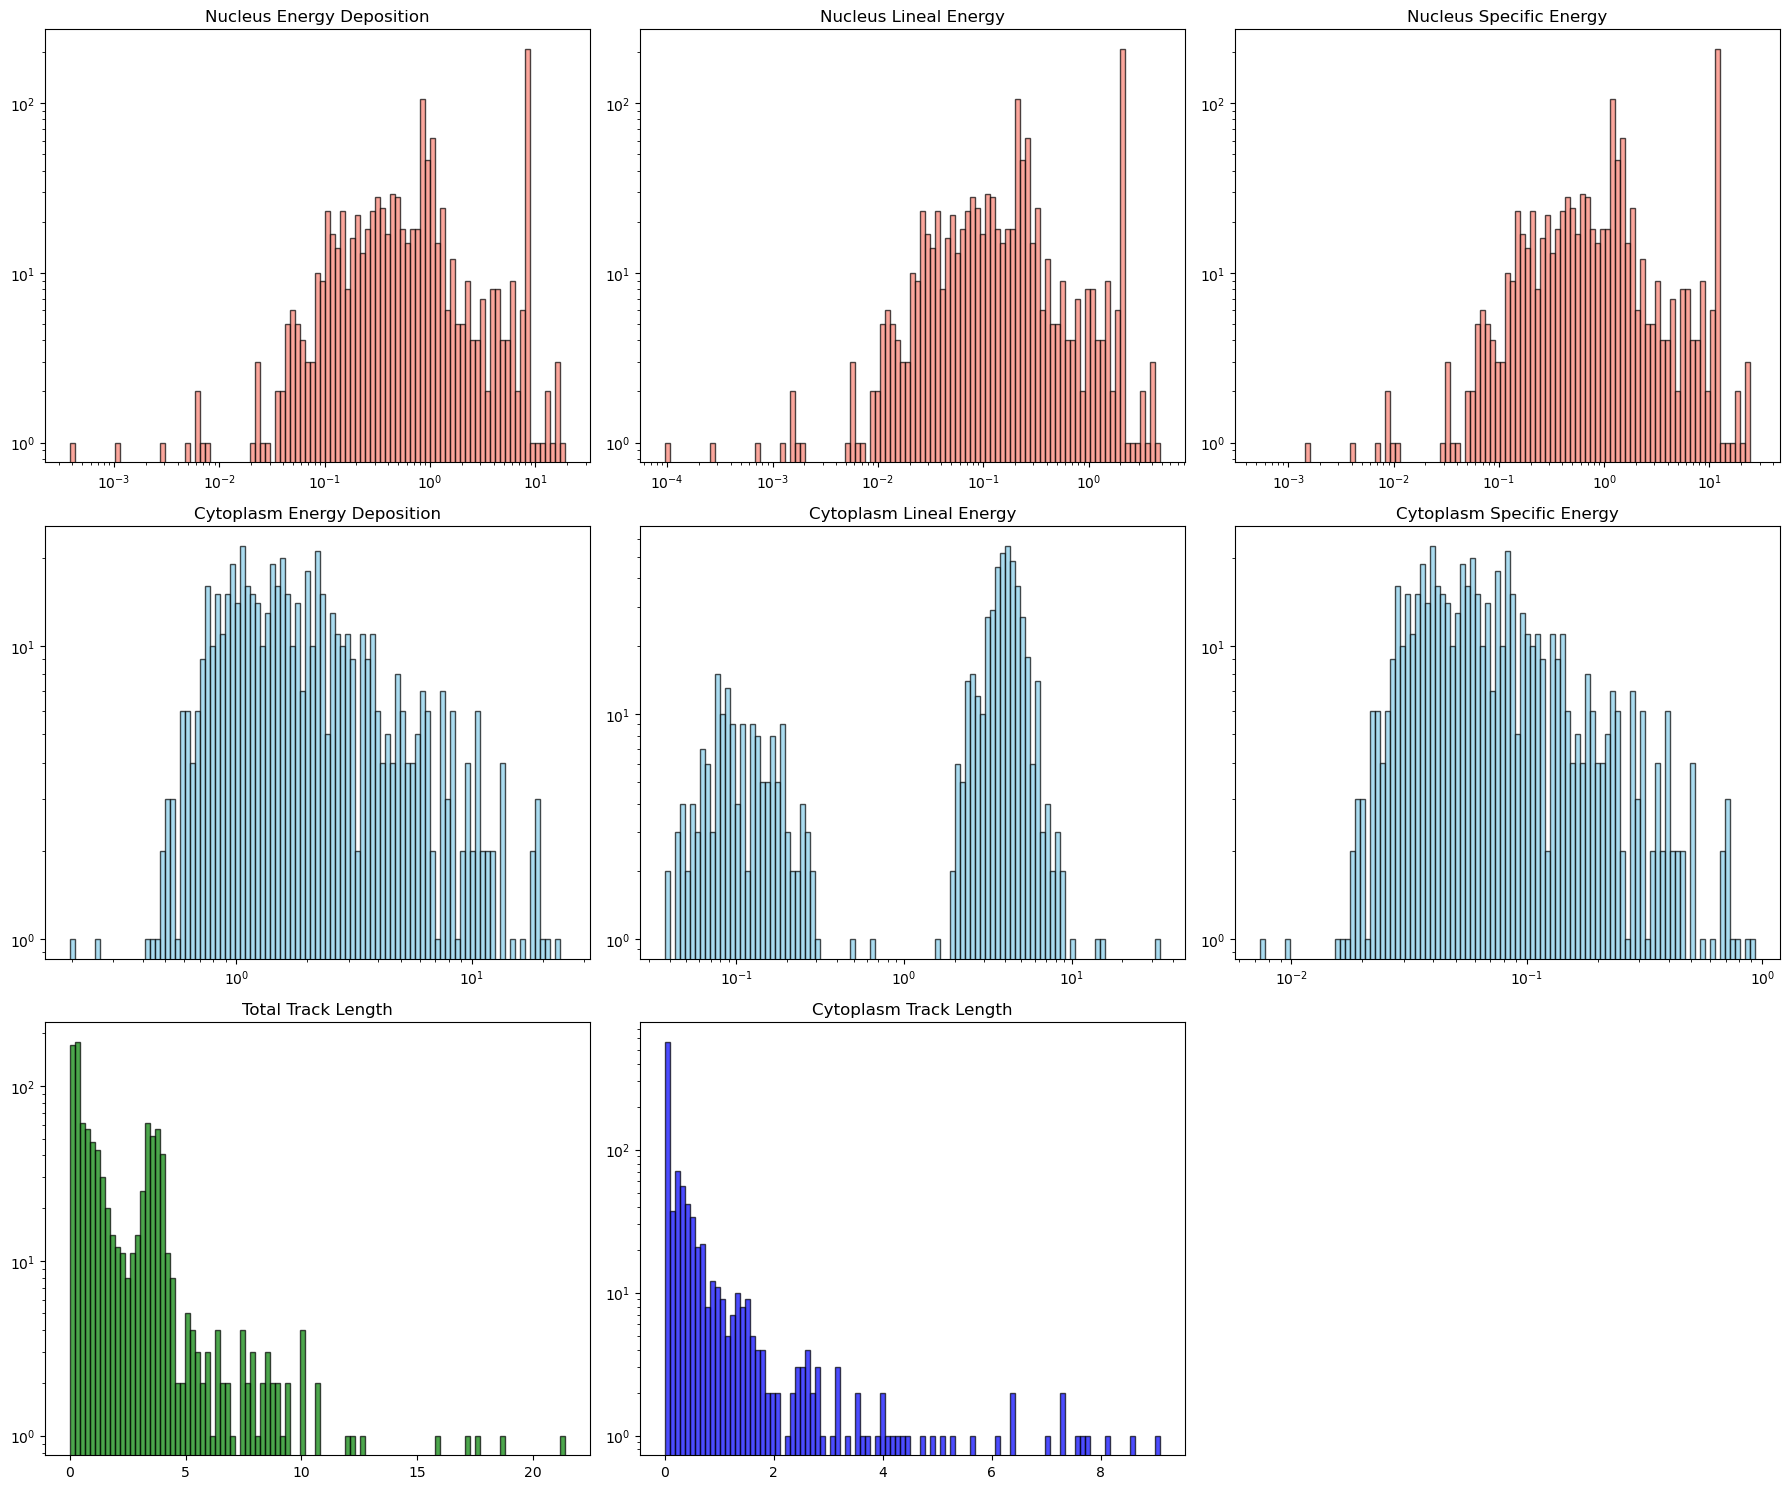

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Definizione corretta e coerente dei nomi
nomi_colonne = [
    "EdepNuc_keV", 
    "yNuc_keV_um", 
    "zNuc_mGy", 
    "EdepCyto_keV", 
    "yCyto_keV_um", 
    "zCyto_mGy", 
    "TotalTrackLength_um",
    "CytoTrackLength_um"
]

# 2. Caricamento
df = pd.read_csv('output/microdosimetria_nt_Micro.csv', comment='#', names=nomi_colonne, sep=',')

# 3. Verifica
print("Colonne rilevate:", df.columns.tolist())

# Configurazione del layout 3x3
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

# Definizione dei dati e delle label (ora il nome della colonna coincide!)
plot_configs = [
    ('EdepNuc_keV', 'Nucleus Energy Deposition', 'Energy [keV]', 'salmon'),
    ('yNuc_keV_um', 'Nucleus Lineal Energy', 'y [keV/µm]', 'salmon'),
    ('zNuc_mGy', 'Nucleus Specific Energy', 'z [mGy]', 'salmon'),
    ('EdepCyto_keV', 'Cytoplasm Energy Deposition', 'Energy [keV]', 'skyblue'),
    ('yCyto_keV_um', 'Cytoplasm Lineal Energy', 'y [keV/µm]', 'skyblue'),
    ('zCyto_mGy', 'Cytoplasm Specific Energy', 'z [mGy]', 'skyblue'),
    ('TotalTrackLength_um', 'Total Track Length', 'Length [µm]', 'green'),
    ('CytoTrackLength_um', 'Cytoplasm Track Length', 'Length [µm]', 'blue')
]

# Loop per generare i grafici
# Loop per generare i grafici
for i, (col, title, xlabel, color) in enumerate(plot_configs):
    data = df[col].dropna()
    # Per la TrackLength usiamo bin lineari o logaritmici a seconda dei dati
    if col == 'TotalTrackLength_um' or col == 'CytoTrackLength_um':
        bins = np.linspace(data.min(), data.max(), 100)
        axes[i].set_xscale('linear')
        axes[i].set_yscale('linear')
    else:
        bins = np.logspace(np.log10(data[data>0].min()), np.log10(data.max()), 100)
        axes[i].set_xscale('log')
        axes[i].set_yscale('linear')

    axes[i].hist(data, bins=bins, color=color, alpha=0.7, edgecolor='black')
    axes[i].set_yscale('log')
    axes[i].set_title(title)
    axes[i].set_xlabel(xlabel)
    axes[i].set_ylabel('Frequency')

# Nascondi gli ultimi 2 grafici vuoti
for i in range(len(plot_configs), 9):
    axes[i].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
df_short = df[df['TrackLength_um'] < 12]
df_long = df[df['TrackLength_um'] >= 12]
# Calcolo della media e deviazione standard per TrackLength
mean_short = df_short['TrackLength_um'].mean()
std_short = df_short['TrackLength_um'].std()
mean_long = df_long['TrackLength_um'].mean()
std_long = df_long['TrackLength_um'].std()
print(f"Track Length < 12 µm: Media = {mean_short:.2f} µm, Deviazione Standard = {std_short:.2f} µm")
print(f"Track Length >= 12 µm: Media = {mean_long:.2f} µm, Deviazione Standard = {std_long:.2f} µm")


Track Length < 12 µm: Media = 0.45 µm, Deviazione Standard = 1.08 µm
Track Length >= 12 µm: Media = nan µm, Deviazione Standard = nan µm
